#Imports and config

In [5]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)


#Loading full raw dataset

In [7]:
df = pd.read_csv("financial_fraud_detection_dataset.csv")
df.head()


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


#Creating 10k chronological batches

In [9]:
BATCH_SIZE = 125000
BATCHES = 4
TOTAL_ROWS = BATCH_SIZE * BATCHES

df_sorted = df.sort_values("timestamp").reset_index(drop=True).iloc[:TOTAL_ROWS].copy()
print(df_sorted.shape)

# Save batches
names_3 = ["batch1_train.csv", "batch2_test.csv", "batch3_stream.csv"]
names_4 = names_3 + ["batch4_stream.csv"]
names = names_4 if BATCHES == 4 else names_3

start = 0
for i, name in enumerate(names, start=1):
    part = df_sorted.iloc[start:start+BATCH_SIZE].copy()
    part.to_csv(DATA_PROCESSED / name, index=False)
    print(name, part.shape, f"fraud_rate={part['is_fraud'].mean():.5f}")
    start += BATCH_SIZE


(500000, 18)
batch1_train.csv (125000, 18) fraud_rate=0.03502
batch2_test.csv (125000, 18) fraud_rate=0.03543
batch3_stream.csv (125000, 18) fraud_rate=0.03590
batch4_stream.csv (125000, 18) fraud_rate=0.03575


#Loading the working batches

In [10]:
train = pd.read_csv(DATA_PROCESSED / "batch1_train.csv")
test  = pd.read_csv(DATA_PROCESSED / "batch2_test.csv")
stream1 = pd.read_csv(DATA_PROCESSED / "batch3_stream.csv")
stream2 = None
if (DATA_PROCESSED / "batch4_stream.csv").exists():
    stream2 = pd.read_csv(DATA_PROCESSED / "batch4_stream.csv")

for name, part in [("train", train), ("test", test), ("stream1", stream1), ("stream2", stream2)]:
    if part is None: continue
    print(f"{name:7s} shape={part.shape}, fraud_rate={part['is_fraud'].mean():.5f}")


train   shape=(125000, 18), fraud_rate=0.03502
test    shape=(125000, 18), fraud_rate=0.03543
stream1 shape=(125000, 18), fraud_rate=0.03590
stream2 shape=(125000, 18), fraud_rate=0.03575


#EDA - Class imbalance & basic stats

In [11]:
def summarize_split(df, label_col="is_fraud"):
    n = len(df)
    pos = df[label_col].sum()
    print(f"Rows={n}, Positives={int(pos)} ({pos/n:.4%})")

print("TRAIN"); summarize_split(train)
print("TEST"); summarize_split(test)
print("STREAM1"); summarize_split(stream1)
if stream2 is not None:
    print("STREAM2"); summarize_split(stream2)

# Amount & Time sanity
train[["amount","timestamp"]].describe()


TRAIN
Rows=125000, Positives=4378 (3.5024%)
TEST
Rows=125000, Positives=4429 (3.5432%)
STREAM1
Rows=125000, Positives=4488 (3.5904%)
STREAM2
Rows=125000, Positives=4469 (3.5752%)


,amount
count,125000.000000
mean,360.517163
std,472.568531
min,0.010000
25%,26.630000
50%,138.760000
75%,505.352500
max,3038.670000


#Simple Visuals

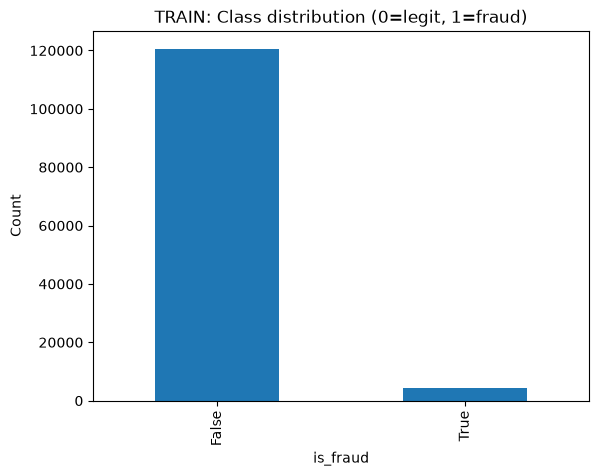

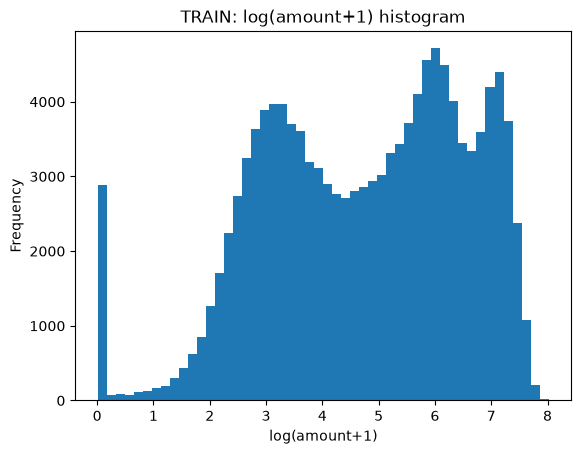

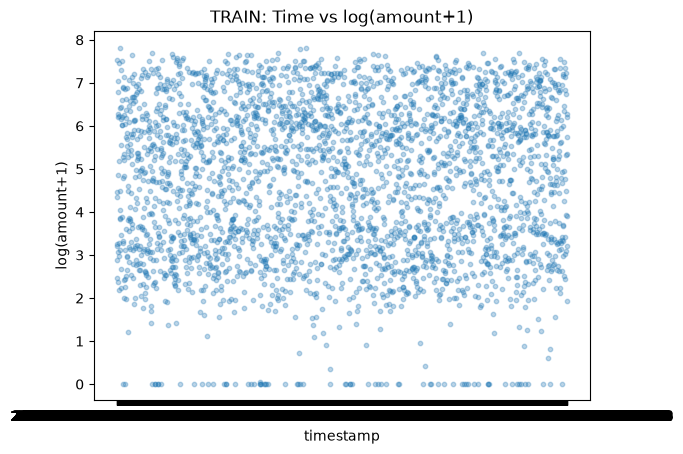

In [12]:
# 1) Imbalance bar
counts = train["is_fraud"].value_counts().sort_index()
plt.figure()
counts.plot(kind="bar")
plt.title("TRAIN: Class distribution (0=legit, 1=fraud)")
plt.xlabel("is_fraud"); plt.ylabel("Count")
plt.show()

# 2) Amount histogram (log1p to see tail)
plt.figure()
plt.hist(np.log1p(train["amount"]), bins=50)
plt.title("TRAIN: log(amount+1) histogram")
plt.xlabel("log(amount+1)"); plt.ylabel("Frequency")
plt.show()

# 3) Time vs Amount scatter (thin sample for speed)
sample = train.sample(min(3000, len(train)), random_state=RANDOM_STATE)
plt.figure()
plt.scatter(sample["timestamp"], np.log1p(sample["amount"]), alpha=0.3, s=10)
plt.title("TRAIN: Time vs log(amount+1)")
plt.xlabel("timestamp"); plt.ylabel("log(amount+1)")
plt.show()


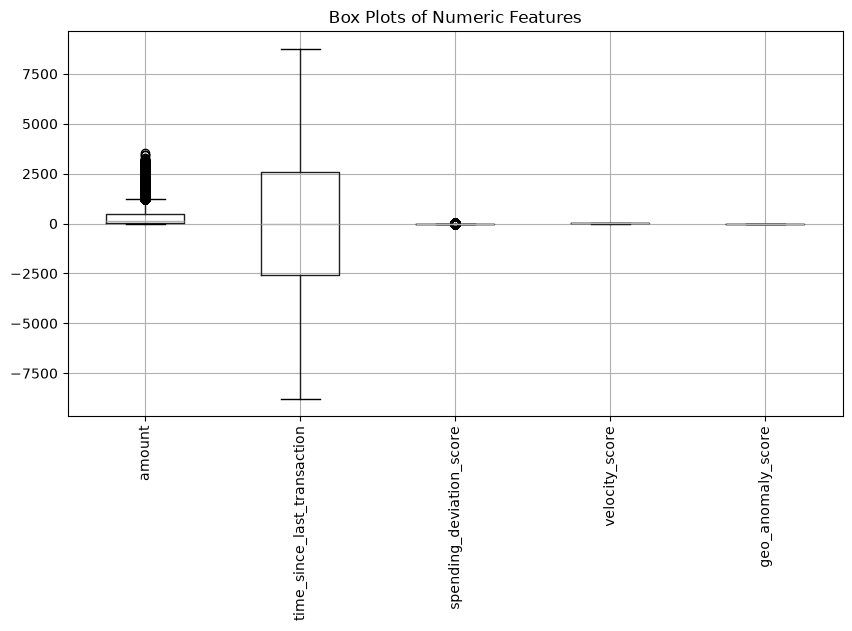

In [13]:
numeric_cols = [
    'amount',
    'time_since_last_transaction',
    'spending_deviation_score',
    'velocity_score',
    'geo_anomaly_score'
]

df[numeric_cols].boxplot(figsize=(10, 5))

plt.title('Box Plots of Numeric Features')
plt.xticks(rotation=90)
plt.show()

In [14]:
print(train.dtypes)

transaction_id                     str
timestamp                          str
sender_account                     str
receiver_account                   str
amount                         float64
transaction_type                   str
merchant_category                  str
location                           str
device_used                        str
is_fraud                          bool
fraud_type                         str
time_since_last_transaction    float64
spending_deviation_score       float64
velocity_score                   int64
geo_anomaly_score              float64
payment_channel                    str
ip_address                         str
device_hash                        str
dtype: object
